<a href="https://colab.research.google.com/github/honeykgarg/PyTorch_NN/blob/regression_with_regularization/LinearRegressionWithRegularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt


In [35]:
x_train = np.array([[4.7], [2.4], [7.5], [7.1], [4.3],
                    [7.8], [8.9], [5.2], [4.59], [2.1],
                    [8], [5], [7.5], [5], [4],
                    [8], [5.2], [4.9], [3], [4.7],
                    [4], [4.8], [3.5], [2.1], [4.1]],
                   dtype = np.float32)

y_train = np.array([[2.6], [1.6], [3.09], [2.4], [2.4],
                    [3.3], [2.6], [1.96], [3.13], [1.76],
                    [3.2], [2.1], [1.6], [2.5], [2.2],
                    [2.75], [2.4], [1.8], [1], [2],
                    [1.6], [2.4], [2.6], [1.5], [3.1]],
                   dtype = np.float32)


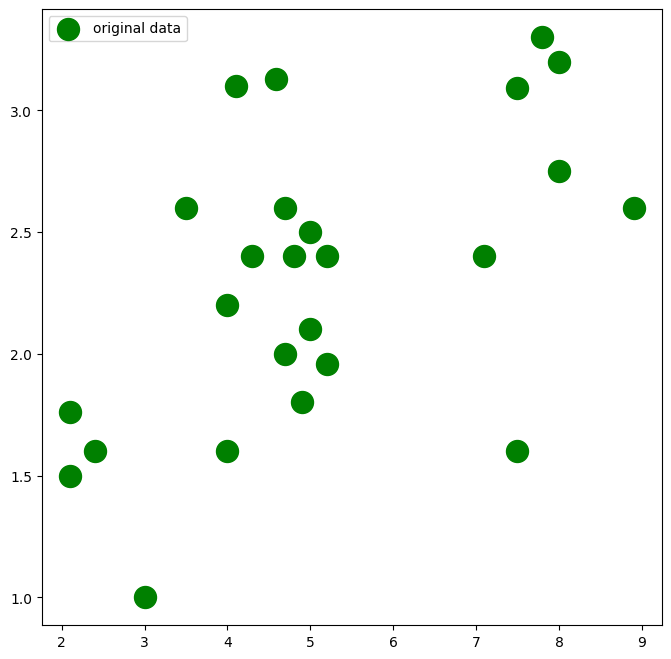

In [36]:
plt.figure(figsize=(8,8))
plt.scatter(x_train, y_train, label = 'original data', s=250, c='g')
plt.legend()
plt.show()

In [37]:
X_train = torch.from_numpy(x_train)
Y_train = torch.from_numpy(y_train)

print('requires_grad for X_train: ', X_train.requires_grad, '\n')
print('requires_grad for Y_train: ', Y_train.requires_grad)

requires_grad for X_train:  False 

requires_grad for Y_train:  False


In [38]:
input_size = 1
hidden_size = 1
output_size = 1
learning_rate = 0.001

In [39]:
w1 = torch.rand(input_size, hidden_size, requires_grad = True)
w1.shape

torch.Size([1, 1])

In [40]:
b1 = torch.rand(hidden_size, output_size, requires_grad = True)
b1.shape

torch.Size([1, 1])

In [41]:
w1

tensor([[0.1459]], requires_grad=True)

In [42]:
b1

tensor([[0.4808]], requires_grad=True)

In [43]:
# Regularization hyperparameter
alpha = 0.8

In [44]:
for iter in range(1,5001):
  y_pred = X_train.mm(w1).add(b1)
  #print(y_pred)

  ridge_reg_penalty = (w1.pow(2))
  loss = ((y_pred - Y_train).pow(2).sum()) + (alpha*ridge_reg_penalty)

  if iter % 500  == 0:
    print(iter, loss.item())

  loss.backward()

  with torch.no_grad():
    w1 -= learning_rate * w1.grad
    b1 -= learning_rate *b1.grad

    w1.grad.zero_()
    b1.grad.zero_()

500 6.129546165466309
1000 6.122975826263428
1500 6.122959136962891
2000 6.122958183288574
2500 6.122958183288574
3000 6.122958183288574
3500 6.122958183288574
4000 6.122958183288574
4500 6.122958183288574
5000 6.122958183288574


In [45]:
print('w1:', w1)
print('b1:', b1)

w1: tensor([[0.1749]], requires_grad=True)
b1: tensor([[1.4055]], requires_grad=True)


In [46]:
x_train_tensor = torch.from_numpy(x_train)
x_train_tensor

tensor([[4.7000],
        [2.4000],
        [7.5000],
        [7.1000],
        [4.3000],
        [7.8000],
        [8.9000],
        [5.2000],
        [4.5900],
        [2.1000],
        [8.0000],
        [5.0000],
        [7.5000],
        [5.0000],
        [4.0000],
        [8.0000],
        [5.2000],
        [4.9000],
        [3.0000],
        [4.7000],
        [4.0000],
        [4.8000],
        [3.5000],
        [2.1000],
        [4.1000]])

In [47]:
predicted_values= x_train_tensor.mm(w1).add(b1)
predicted_values

tensor([[2.2274],
        [1.8252],
        [2.7171],
        [2.6471],
        [2.1575],
        [2.7696],
        [2.9619],
        [2.3149],
        [2.2082],
        [1.7727],
        [2.8045],
        [2.2799],
        [2.7171],
        [2.2799],
        [2.1050],
        [2.8045],
        [2.3149],
        [2.2624],
        [1.9301],
        [2.2274],
        [2.1050],
        [2.2449],
        [2.0176],
        [1.7727],
        [2.1225]], grad_fn=<AddBackward0>)

In [48]:
# Plot using MatPlotLib

predicted_numpy_array = predicted_values.detach().numpy()
predicted_numpy_array

array([[2.2274206],
       [1.8251936],
       [2.7170882],
       [2.6471357],
       [2.157468 ],
       [2.7695525],
       [2.9619217],
       [2.314861 ],
       [2.2081838],
       [1.7727293],
       [2.8045287],
       [2.2798848],
       [2.7170882],
       [2.2798848],
       [2.1050036],
       [2.8045287],
       [2.314861 ],
       [2.2623968],
       [1.9301224],
       [2.2274206],
       [2.1050036],
       [2.2449088],
       [2.017563 ],
       [1.7727293],
       [2.1224918]], dtype=float32)

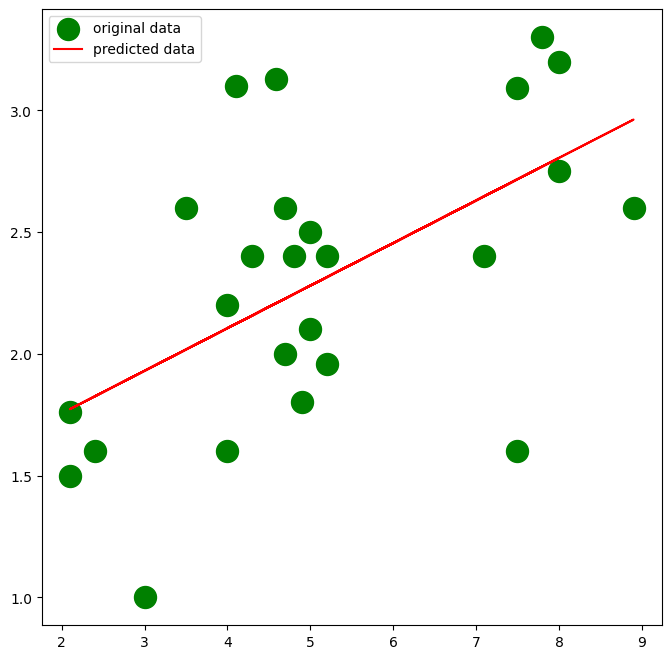

In [49]:
plt.figure(figsize=(8,8))
plt.scatter(x_train, y_train, label = 'original data', s=250, c='g')
plt.plot(x_train, predicted_numpy_array, label = 'predicted data', c='r')
plt.legend()
plt.show()